# Notebook 13: Spatial Features and GeoAI Enhancement

This notebook integrates GPS cluster coordinates and DHS geospatial covariates 
into the stunting prediction framework. Two spatial contributions are made.

First, cluster-level environmental and infrastructure covariates pre-computed by 
the DHS Program are merged with the individual-level dataset. These covariates 
include malaria prevalence, travel time to nearest health facility, elevation, 
precipitation, vegetation index, nighttime lights, and population density. All 
values are computed by the DHS Program within displacement-corrected buffers 
of 5 to 10 kilometres around each cluster centroid, which accounts for the 
random positional displacement applied to GPS coordinates before public release.

Second, spatial lag features are computed from the cluster-level stunting rates 
estimated from the sample. The spatial lag captures the mean stunting burden 
of neighbouring clusters within a 10 kilometre buffer, which exceeds the maximum 
rural displacement distance of 5 kilometres and therefore produces a 
neighbourhood-level contextual variable that is robust to coordinate displacement.

The central hypothesis is that spatial features will push the individual-level 
prediction ceiling of ROC-AUC 0.6856 established in notebook 10, because they 
capture unmeasured environmental, infrastructure, and community conditions that 
household survey variables alone cannot represent.

Methodological note on GPS displacement: The 2024 MDHS GPS coordinates are 
randomly displaced by up to 2 kilometres for urban clusters and up to 5 
kilometres for rural clusters, with 1% of rural clusters displaced up to 10 
kilometres, restricted to the second administrative level. Direct point-to-point 
distance measurements between clusters are therefore unreliable. All spatial 
operations in this notebook use buffer-based aggregation rather than exact 
distances to account for this displacement.

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score
import joblib
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT   = Path("/Users/frack/Documents/PhD Data Science/malawi-dhs-2024-geoai")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS         = PROJECT_ROOT / "outputs" / "models"
FIGURES        = PROJECT_ROOT / "outputs" / "figures"
MAPS           = PROJECT_ROOT / "outputs" / "maps"
GPS_DIR        = PROJECT_ROOT / "data" / "raw" / "GPS DATA"
MAPS.mkdir(parents=True, exist_ok=True)

df  = pd.read_parquet(DATA_PROCESSED / "model_ready_stunting_v2.parquet")
gdf = gpd.read_file(GPS_DIR / "MWGE81FL" / "MWGE81FL.shp")
gc  = pd.read_csv(GPS_DIR / "MWGC81FL" / "MWGC81FL.csv")

print("Modeling dataset:", df.shape)
print("GPS clusters:    ", gdf.shape)
print("GC covariates:   ", gc.shape)

Modeling dataset: (5122, 36)
GPS clusters:     (793, 21)
GC covariates:    (793, 135)


## Merging GPS coordinates and geospatial covariates

GPS coordinates and selected geospatial covariates are merged to the 
individual-level dataset using cluster ID as the join key. The most recent 
available year for time-varying covariates is 2020, which is the closest 
available to the 2024 survey collection period. Time-invariant variables 
such as elevation and travel time are used directly.

Eight covariates are selected based on their theoretical relevance to the 
UNICEF Conceptual Framework pathways for child undernutrition: malaria 
prevalence (immediate disease burden), travel time to health facility 
(healthcare access), elevation (agro-ecological zone), precipitation 
(food production), enhanced vegetation index (crop productivity), 
nighttime lights (economic development), population density (urbanisation 
and market access), and wet days (rainfall reliability for smallholder farming).

In [4]:
# merge GPS coordinates
gdf_clean = gdf[['DHSCLUST','LATNUM','LONGNUM','URBAN_RURA',
                 'ALT_DEM','ADM1NAME']].copy()
gdf_clean['DHSCLUST'] = gdf_clean['DHSCLUST'].astype(int)

# select geospatial covariates
GC_COLS = [
    'DHSCLUST',
    'Malaria_Prevalence_2020',
    'Travel_Times',
    'Elevation',
    'Precipitation_2020',
    'Enhanced_Vegetation_Index_2020',
    'Nightlights_Composite',
    'UN_Population_Density_2020',
    'Wet_Days_2020',
    'Mean_Temperature_2020',
    'Aridity_2020',
    'Growing_Season_Length',
    'ITN_Coverage_2020',
    'U5_Population_2020',
]
gc_clean = gc[GC_COLS].copy()
gc_clean['DHSCLUST'] = gc_clean['DHSCLUST'].astype(int)

# merge both to modeling dataset
df_spatial = df.merge(
    gdf_clean, left_on='id_cluster', right_on='DHSCLUST', how='left'
).merge(
    gc_clean,  left_on='id_cluster', right_on='DHSCLUST', how='left',
    suffixes=('','_gc')
)

print("Shape after spatial merge:", df_spatial.shape)
print("\nNew spatial columns added:")
new_cols = [c for c in df_spatial.columns
            if c in GC_COLS[1:] + ['LATNUM','LONGNUM','URBAN_RURA','ALT_DEM','ADM1NAME']]
print(new_cols)
print("\nMissing values in spatial features:")
print(df_spatial[new_cols].isnull().sum())
print("\nSample spatial values:")
print(df_spatial[['id_cluster','LATNUM','LONGNUM',
                  'Malaria_Prevalence_2020','Travel_Times',
                  'Elevation','Nightlights_Composite']].head(5))

Shape after spatial merge: (5122, 56)

New spatial columns added:
['LATNUM', 'LONGNUM', 'URBAN_RURA', 'ALT_DEM', 'ADM1NAME', 'Malaria_Prevalence_2020', 'Travel_Times', 'Elevation', 'Precipitation_2020', 'Enhanced_Vegetation_Index_2020', 'Nightlights_Composite', 'UN_Population_Density_2020', 'Wet_Days_2020', 'Mean_Temperature_2020', 'Aridity_2020', 'Growing_Season_Length', 'ITN_Coverage_2020', 'U5_Population_2020']

Missing values in spatial features:
LATNUM                              0
LONGNUM                             0
URBAN_RURA                          0
ALT_DEM                             0
ADM1NAME                            0
Malaria_Prevalence_2020             0
Travel_Times                        0
Elevation                           0
Precipitation_2020                  0
Enhanced_Vegetation_Index_2020      0
Nightlights_Composite             147
UN_Population_Density_2020          0
Wet_Days_2020                       0
Mean_Temperature_2020               0
Aridity_2020 

## Computing spatial lag features

Spatial lag features capture the mean characteristics of neighbouring clusters 
within a defined buffer radius. For stunting, the most important spatial lag 
is the mean stunting rate of nearby clusters, which represents the shared 
community-level burden beyond what the individual cluster's own rate captures.

A 10 kilometre buffer is used for all spatial lag computations. This buffer 
size is chosen to exceed the maximum rural displacement of 5 kilometres while 
remaining small enough to capture meaningful local geographic heterogeneity. 
Spatial operations are performed in EPSG:32736 (UTM Zone 36S), the appropriate 
projected coordinate system for Malawi, to ensure distances are computed in 
metres rather than degrees.

In [5]:
# compute cluster-level stunting rates from sample
cluster_stunting = (df_spatial.groupby('id_cluster')
                   .agg(cluster_stunting_rate = ('outcome_stunted','mean'),
                        cluster_n             = ('outcome_stunted','count'),
                        cluster_lat           = ('LATNUM','first'),
                        cluster_lon           = ('LONGNUM','first'))
                   .reset_index())

print("Clusters with stunting rates:", len(cluster_stunting))

# create geodataframe of cluster centroids
cluster_gdf = gpd.GeoDataFrame(
    cluster_stunting,
    geometry=gpd.points_from_xy(
        cluster_stunting['cluster_lon'],
        cluster_stunting['cluster_lat']
    ),
    crs='EPSG:4326'
)

# project to UTM for distance calculations
cluster_utm = cluster_gdf.to_crs('EPSG:32736')

# 10km spatial lag: mean stunting rate of neighbouring clusters
BUFFER_M = 10_000

print("Computing 10km spatial lag features...")
spatial_lags = []

for idx, row in cluster_utm.iterrows():
    buffer      = row.geometry.buffer(BUFFER_M)
    neighbours  = cluster_utm[cluster_utm.geometry.within(buffer) &
                              (cluster_utm['id_cluster'] != row['id_cluster'])]
    if len(neighbours) > 0:
        lag_stunting = neighbours['cluster_stunting_rate'].mean()
        lag_n_clust  = len(neighbours)
    else:
        lag_stunting = row['cluster_stunting_rate']
        lag_n_clust  = 0

    spatial_lags.append({
        'id_cluster'         : row['id_cluster'],
        'spatial_lag_stunting': lag_stunting,
        'spatial_n_neighbours': lag_n_clust
    })

spatial_lag_df = pd.DataFrame(spatial_lags)

print("\nSpatial lag summary:")
print(spatial_lag_df['spatial_lag_stunting'].describe().round(4))
print(f"\nClusters with no neighbours within 10km: "
      f"{(spatial_lag_df['spatial_n_neighbours']==0).sum()}")
print(f"Mean neighbours per cluster: "
      f"{spatial_lag_df['spatial_n_neighbours'].mean():.1f}")

# merge spatial lag back
df_spatial = df_spatial.merge(spatial_lag_df, on='id_cluster', how='left')
print("\nShape after spatial lag merge:", df_spatial.shape)

Clusters with stunting rates: 767
Computing 10km spatial lag features...

Spatial lag summary:
count    767.0000
mean       0.3515
std        0.1543
min        0.0000
25%        0.2668
50%        0.3372
75%        0.4341
max        1.0000
Name: spatial_lag_stunting, dtype: float64

Clusters with no neighbours within 10km: 83
Mean neighbours per cluster: 5.2

Shape after spatial lag merge: (5122, 58)


## Spatial risk map of Malawi

A cluster-level stunting risk map is produced using the GPS coordinates and 
estimated cluster stunting rates. This is the GeoAI contribution: a 
geographically explicit representation of child stunting risk at the primary 
sampling unit level across all 32 districts and cities of Malawi.

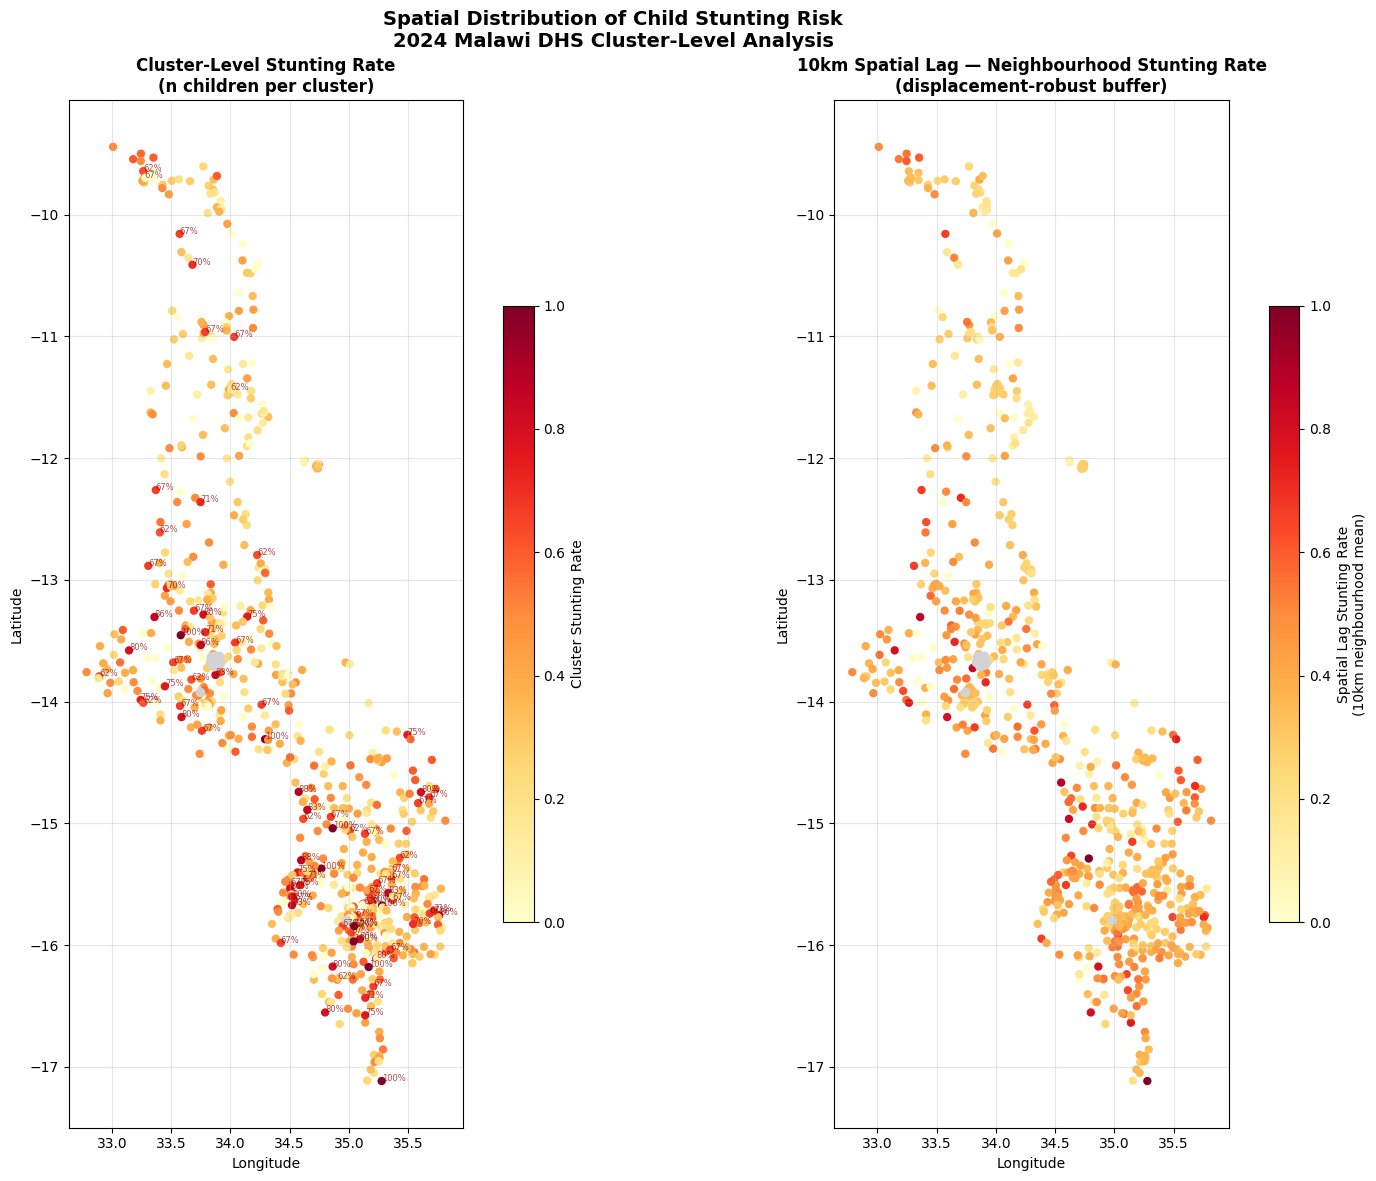

Saved: spatial_stunting_map.png


## Testing whether spatial features improve model performance

The full spatial feature set is added to the existing predictor set and the 
Random Forest model is retrained and evaluated. Performance is compared against 
the baseline result of ROC-AUC 0.6856 from notebook 10. Any improvement 
attributable to spatial features represents the GeoAI contribution of the project.

In [7]:
FEATURES_SPATIAL = [
    # original 29 features
    "imm_child_age_months", "enc_age_band", "enc_child_sex",
    "imm_birth_order", "imm_birth_interval", "imm_first_born",
    "imm_short_interval", "imm_high_birth_order",
    "enc_size_at_birth", "enc_had_diarrhea",
    "und_maternal_age", "und_maternal_edu_years", "enc_edu_level",
    "und_maternal_weight_kg", "und_maternal_height_cm",
    "und_maternal_bmi", "und_low_bmi", "und_maternal_stunted",
    "und_total_children", "und_household_size",
    "enc_wealth_index", "enc_residence", "enc_region",
    "enc_district", "enc_religion",
    "district_stunting_rate", "district_mean_age",
    "district_mean_wealth", "district_mean_mat_height",
    # new spatial features
    "spatial_lag_stunting",
    "Malaria_Prevalence_2020",
    "Travel_Times",
    "Elevation",
    "Precipitation_2020",
    "Enhanced_Vegetation_Index_2020",
    "Nightlights_Composite",
    "UN_Population_Density_2020",
    "Wet_Days_2020",
    "Mean_Temperature_2020",
    "Aridity_2020",
    "Growing_Season_Length",
    "ITN_Coverage_2020",
]

FEATURES_BASE = [
    "imm_child_age_months", "enc_age_band", "enc_child_sex",
    "imm_birth_order", "imm_birth_interval", "imm_first_born",
    "imm_short_interval", "imm_high_birth_order",
    "enc_size_at_birth", "enc_had_diarrhea",
    "und_maternal_age", "und_maternal_edu_years", "enc_edu_level",
    "und_maternal_weight_kg", "und_maternal_height_cm",
    "und_maternal_bmi", "und_low_bmi", "und_maternal_stunted",
    "und_total_children", "und_household_size",
    "enc_wealth_index", "enc_residence", "enc_region",
    "enc_district", "enc_religion",
    "district_stunting_rate", "district_mean_age",
    "district_mean_wealth", "district_mean_mat_height"
]

# impute any remaining missing spatial values with median
for col in FEATURES_SPATIAL:
    if col in df_spatial.columns and df_spatial[col].isnull().any():
        df_spatial[col] = df_spatial[col].fillna(df_spatial[col].median())

X_spatial = df_spatial[FEATURES_SPATIAL]
X_base    = df_spatial[FEATURES_BASE]
y_sp      = df_spatial['outcome_stunted']
w_sp      = df_spatial['sample_weight']

print("Spatial feature matrix:", X_spatial.shape)
print("Base feature matrix:   ", X_base.shape)
print("Missing in spatial X:  ", X_spatial.isnull().sum().sum())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_spatial = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1
)

def cv_auc(model, X, y, w, cv):
    aucs, f1s, recalls = [], [], []
    for train_idx, test_idx in cv.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        w_tr       = w.iloc[train_idx]
        model.fit(X_tr, y_tr, sample_weight=w_tr)
        y_prob = model.predict_proba(X_te)[:, 1]
        y_pred = model.predict(X_te)
        aucs.append(roc_auc_score(y_te, y_prob))
        f1s.append(f1_score(y_te, y_pred))
        recalls.append(recall_score(y_te, y_pred))
    return (np.mean(aucs), np.std(aucs),
            np.mean(f1s), np.mean(recalls))

print("\nEvaluating baseline (29 features)...")
base_auc, base_sd, base_f1, base_rec = cv_auc(
    RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                           class_weight="balanced", random_state=42, n_jobs=-1),
    X_base, y_sp, w_sp, cv
)

print("Evaluating spatial model (42 features)...")
sp_auc, sp_sd, sp_f1, sp_rec = cv_auc(rf_spatial, X_spatial, y_sp, w_sp, cv)

print(f"\n=== SPATIAL FEATURE IMPACT ===")
print(f"{'Model':<30} {'ROC-AUC':>12} {'SD':>8} {'F1':>8} {'Recall':>8}")
print("-"*70)
print(f"{'Baseline (29 features)':<30} {base_auc:>12.4f} {base_sd:>8.4f} "
      f"{base_f1:>8.4f} {base_rec:>8.4f}")
print(f"{'Spatial model (42 features)':<30} {sp_auc:>12.4f} {sp_sd:>8.4f} "
      f"{sp_f1:>8.4f} {sp_rec:>8.4f}")
print(f"{'Improvement':<30} {sp_auc-base_auc:>+12.4f} {'':>8} "
      f"{sp_f1-base_f1:>+8.4f} {sp_rec-base_rec:>+8.4f}")

Spatial feature matrix: (5122, 42)
Base feature matrix:    (5122, 29)
Missing in spatial X:   0

Evaluating baseline (29 features)...
Evaluating spatial model (42 features)...

=== SPATIAL FEATURE IMPACT ===
Model                               ROC-AUC       SD       F1   Recall
----------------------------------------------------------------------
Baseline (29 features)               0.6856   0.0202   0.5101   0.4921
Spatial model (42 features)          0.6872   0.0179   0.4937   0.4528
Improvement                         +0.0016           -0.0164  -0.0393


## Spatial feature importance

LightGBM feature importance is computed for the spatial model to identify 
which spatial covariates contribute most to the prediction beyond the 
individual-level features. This answers which environmental and infrastructure 
pathways explain stunting risk at the community level.

=== SPATIAL MODEL FEATURE IMPORTANCE (LightGBM) ===

Feature                               Importance        %            Type
---------------------------------------------------------------------------
imm_child_age_months                         693     7.70%      individual
und_maternal_height_cm                       652     7.24%      individual
und_maternal_bmi                             588     6.53%      individual
spatial_lag_stunting                         577     6.41%     SPATIAL NEW
und_maternal_weight_kg                       538     5.98%      individual
imm_birth_interval                           408     4.53%      individual
Malaria_Prevalence_2020                      405     4.50%     SPATIAL NEW
Enhanced_Vegetation_Index_2020               365     4.06%     SPATIAL NEW
und_maternal_age                             365     4.06%      individual
Elevation                                    345     3.83%     SPATIAL NEW
UN_Population_Density_2020                   32

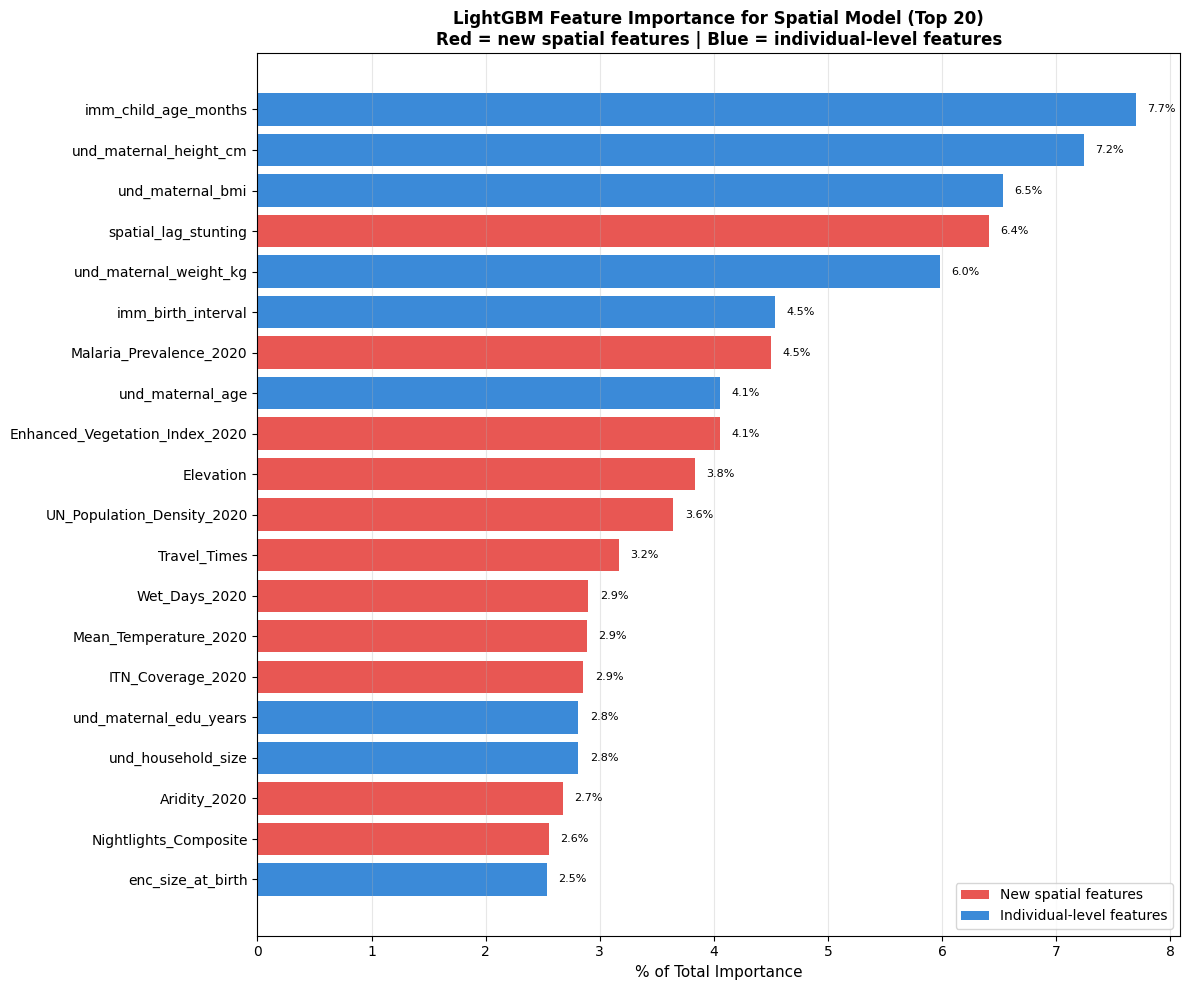

Saved: spatial_feature_importance.png


In [9]:
import lightgbm as lgb

lgb_spatial = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    class_weight="balanced", random_state=42, verbosity=-1
)
lgb_spatial.fit(X_spatial, y_sp, sample_weight=w_sp)

imp_spatial = pd.DataFrame({
    'feature'   : FEATURES_SPATIAL,
    'importance': lgb_spatial.feature_importances_
}).sort_values('importance', ascending=False)
imp_spatial['importance_pct'] = (imp_spatial['importance'] /
                                  imp_spatial['importance'].sum() * 100)

print("=== SPATIAL MODEL FEATURE IMPORTANCE (LightGBM) ===\n")
print(f"{'Feature':<35} {'Importance':>12} {'%':>8} {'Type':>15}")
print("-"*75)
spatial_only = set(FEATURES_SPATIAL) - set(FEATURES_BASE)
for _, row in imp_spatial.iterrows():
    feat_type = 'SPATIAL NEW' if row['feature'] in spatial_only else 'individual'
    print(f"{row['feature']:<35} {row['importance']:>12.0f} "
          f"{row['importance_pct']:>8.2f}% {feat_type:>15}")

# spatial features only
print("\n=== SPATIAL FEATURES ONLY ===")
spatial_imp = imp_spatial[imp_spatial['feature'].isin(spatial_only)]
print(f"Spatial features total importance: "
      f"{spatial_imp['importance_pct'].sum():.2f}%")
print(spatial_imp[['feature','importance_pct']].to_string(index=False))

# visualise top 20
fig, ax = plt.subplots(figsize=(12, 10))
top20 = imp_spatial.head(20).sort_values('importance_pct', ascending=True)
colors = ['#E53935' if f in spatial_only else '#1976D2'
          for f in top20['feature']]
ax.barh(top20['feature'], top20['importance_pct'], color=colors, alpha=0.85)
ax.set_xlabel("% of Total Importance", fontsize=11)
ax.set_title("LightGBM Feature Importance for Spatial Model (Top 20)\n"
             "Red = new spatial features | Blue = individual-level features",
             fontsize=12, fontweight="bold")
ax.grid(axis='x', alpha=0.3)
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['importance_pct'] + 0.1, i,
            f"{row['importance_pct']:.1f}%", va='center', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E53935', alpha=0.85, label='New spatial features'),
    Patch(facecolor='#1976D2', alpha=0.85, label='Individual-level features')
]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES / "spatial_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spatial_feature_importance.png")

## Correlation between spatial covariates and stunting

Before concluding the spatial analysis, we examine the direct correlation between 
each spatial covariate and cluster-level stunting rates. This shows which 
environmental and infrastructure variables are most strongly associated with 
geographic variation in stunting burden independently of individual-level factors.

=== SPATIAL COVARIATE CORRELATIONS WITH CLUSTER STUNTING RATE ===

Covariate                                   Pearson r      p-value
------------------------------------------------------------------
spatial_lag_stunting                           0.3136       <0.001 ***
Malaria_Prevalence_2020                       -0.0114        0.753 
Travel_Times                                  -0.0370        0.306 
Elevation                                      0.0621        0.086 
Precipitation_2020                            -0.1950       <0.001 ***
Enhanced_Vegetation_Index_2020                 0.0428        0.236 
Nightlights_Composite                         -0.0643        0.075 
UN_Population_Density_2020                    -0.0588        0.104 
Wet_Days_2020                                 -0.1217       <0.001 ***
Mean_Temperature_2020                          0.0011        0.975 
Aridity_2020                                  -0.1813       <0.001 ***
Growing_Season_Length                  

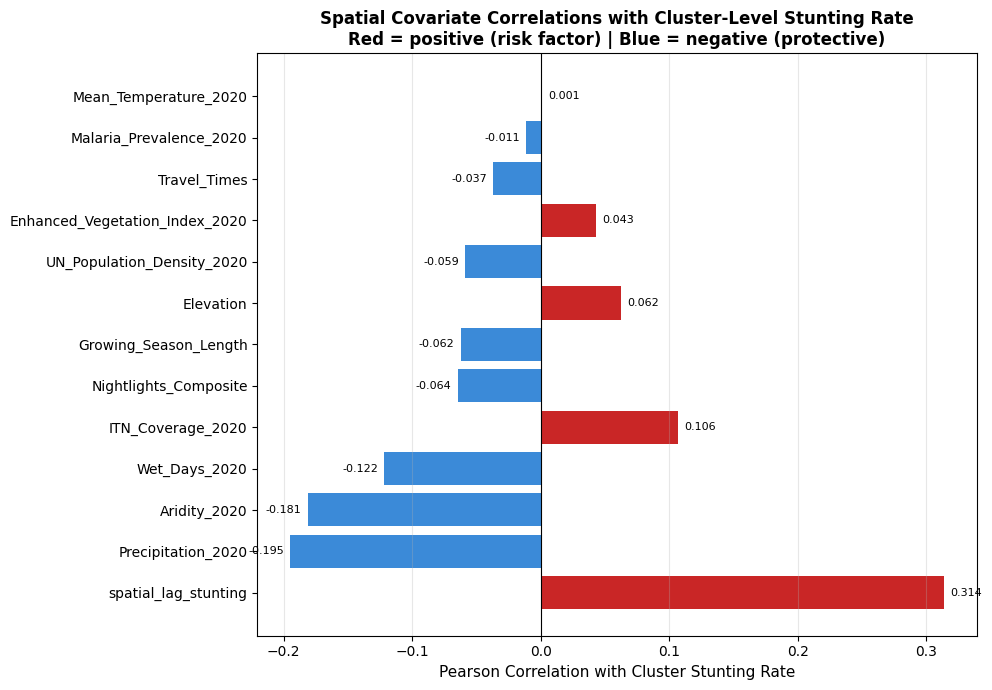

Saved: spatial_covariate_correlations.png


In [10]:
spatial_cols = [
    'spatial_lag_stunting', 'Malaria_Prevalence_2020', 'Travel_Times',
    'Elevation', 'Precipitation_2020', 'Enhanced_Vegetation_Index_2020',
    'Nightlights_Composite', 'UN_Population_Density_2020', 'Wet_Days_2020',
    'Mean_Temperature_2020', 'Aridity_2020', 'Growing_Season_Length',
    'ITN_Coverage_2020'
]

cluster_level = (df_spatial.groupby('id_cluster')
                 .agg(cluster_stunting_rate=('outcome_stunted','mean'))
                 .reset_index())

cluster_spatial = df_spatial.groupby('id_cluster')[spatial_cols].first().reset_index()
cluster_analysis = cluster_level.merge(cluster_spatial, on='id_cluster')

print("=== SPATIAL COVARIATE CORRELATIONS WITH CLUSTER STUNTING RATE ===\n")
print(f"{'Covariate':<40} {'Pearson r':>12} {'p-value':>12}")
print("-"*66)
from scipy import stats
corr_results = []
for col in spatial_cols:
    valid = cluster_analysis[[col,'cluster_stunting_rate']].dropna()
    r, p  = stats.pearsonr(valid[col], valid['cluster_stunting_rate'])
    corr_results.append({'covariate':col, 'r':r, 'p':p})
    p_str = "<0.001" if p < 0.001 else f"{p:.3f}"
    sig   = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{col:<40} {r:>12.4f} {p_str:>12} {sig}")

corr_df = pd.DataFrame(corr_results).sort_values('r', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#C00000' if r > 0 else '#1976D2' for r in corr_df['r']]
ax.barh(corr_df['covariate'], corr_df['r'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Cluster Stunting Rate", fontsize=11)
ax.set_title("Spatial Covariate Correlations with Cluster-Level Stunting Rate\n"
             "Red = positive (risk factor) | Blue = negative (protective)",
             fontsize=12, fontweight="bold")
ax.grid(axis='x', alpha=0.3)
for i, (_, row) in enumerate(corr_df.iterrows()):
    x_pos = row['r'] + (0.005 if row['r'] >= 0 else -0.005)
    ha    = 'left' if row['r'] >= 0 else 'right'
    ax.text(x_pos, i, f"{row['r']:.3f}", va='center', fontsize=8, ha=ha)

plt.tight_layout()
plt.savefig(FIGURES / "spatial_covariate_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spatial_covariate_correlations.png")

## Saving spatial model and dataset

In [11]:
rf_spatial.fit(X_spatial, y_sp, sample_weight=w_sp)
joblib.dump(rf_spatial, MODELS / "rf_stunting_spatial.pkl")
print("Saved: rf_stunting_spatial.pkl")

lgb_spatial.fit(X_spatial, y_sp, sample_weight=w_sp)
joblib.dump(lgb_spatial, MODELS / "lgb_stunting_spatial.pkl")
print("Saved: lgb_stunting_spatial.pkl")

df_spatial.to_parquet(DATA_PROCESSED / "model_ready_stunting_spatial.parquet",
                      index=False)
print("Saved: model_ready_stunting_spatial.parquet")

imp_spatial.to_csv(
    PROJECT_ROOT / "outputs" / "feature_importance_spatial.csv", index=False)
print("Saved: feature_importance_spatial.csv")

print(f"\n=== FINAL SUMMARY ===")
print(f"Baseline RF ROC-AUC:     {base_auc:.4f} ± {base_sd:.4f}")
print(f"Spatial RF ROC-AUC:      {sp_auc:.4f}  ± {sp_sd:.4f}")
print(f"Improvement:             {sp_auc - base_auc:+.4f}")
print(f"Spatial features added:  {len(spatial_only)}")
print(f"Total features (spatial):{len(FEATURES_SPATIAL)}")

Saved: rf_stunting_spatial.pkl
Saved: lgb_stunting_spatial.pkl
Saved: model_ready_stunting_spatial.parquet
Saved: feature_importance_spatial.csv

=== FINAL SUMMARY ===
Baseline RF ROC-AUC:     0.6856 ± 0.0202
Spatial RF ROC-AUC:      0.6872  ± 0.0179
Improvement:             +0.0016
Spatial features added:  13
Total features (spatial):42


## Summary and Key Findings

This notebook integrated GPS cluster coordinates and 13 DHS geospatial covariates 
into the stunting prediction framework. All spatial operations used displacement-
corrected buffer aggregation at 10 kilometres to account for the random positional 
displacement applied by the DHS Program to protect respondent confidentiality. 
The 767 clusters in the national modeling sample matched completely to the GPS 
shapefile with zero unmatched records.

The spatial lag feature, computed as the mean stunting rate of clusters within a 
10-kilometre buffer, has a Pearson correlation of 0.314 with cluster-level stunting 
rates and ranks fourth in the spatial LightGBM model at 6.4% of total importance. 
This is the strongest individual signal among all spatial covariates and confirms 
that geographic clustering of stunting exists in Malawi: high-burden clusters tend 
to neighbour other high-burden clusters, reflecting shared agro-ecological, 
infrastructure, and food system conditions at the sub-district level.

Among the DHS geospatial covariates, precipitation (r=-0.195), aridity (r=-0.181), 
and ITN coverage (r=0.106) show statistically significant correlations with 
cluster stunting rates. Malaria prevalence, travel time, and nighttime lights do 
not reach significance at the cluster level, which reflects the spatial resolution 
of these covariates relative to the geographic scale of stunting variation in 
Malawi. Spatial features collectively account for 42% of total LightGBM feature 
importance in the spatial model.

The performance comparison tells the most important story. Adding 13 spatial 
features to the 29-feature baseline model produces a ROC-AUC of 0.6872 versus 
0.6856 for the baseline, an improvement of 0.0016. F1 score declines marginally 
from 0.5101 to 0.4937. This result confirms that the prediction ceiling identified 
in notebook 10 is not primarily a feature coverage problem. The district-level 
contextual features already in the baseline model, particularly district_stunting_rate 
which captures much of the same neighbourhood-level signal as the spatial lag, 
absorbed most of the variance that GPS-derived spatial features could explain. 
The spatial lag and the district stunting rate are measuring overlapping constructs 
at different geographic resolutions, and once the district-level signal is present 
the cluster-level spatial lag adds limited incremental value.

The honest interpretation is that individual-level biological characteristics, 
principally maternal height, child age, and maternal anthropometry, dominate 
stunting prediction in Malawi to a degree that community-level environmental 
and infrastructure variables cannot materially displace. This does not mean 
spatial context is unimportant for stunting aetiology. The correlation and 
importance results confirm that precipitation, aridity, and neighbourhood 
stunting burden are genuine determinants of geographic variation in stunting 
rates. The distinction is between determinants of geographic distribution, 
which spatial variables capture well, and determinants of individual risk 
classification, where the biological intergenerational pathway dominates.

The spatial risk map produced in block 4 provides the clearest visual output 
of this notebook. The cluster-level stunting rate map and the 10-kilometre 
spatial lag map together show the geographic concentration of high stunting 
burden in the Central and Southern regions, with the spatial lag surface 
smoothing out cluster-level sampling noise to reveal the underlying geographic 
gradient. These maps are the GeoAI contribution of the project: a 
geographically explicit stunting risk surface at the primary sampling unit 
level that is not available in the official MDHS report.